In [2]:

import numpy as np
import xarray as xr
import glob
import os
from scipy import stats, signal
from eofs.standard import Eof
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import warnings


In [39]:
# PARAMETERS

eraNames = ["mgs-tes", "mro-mcs", "combinedwithGap"]
vars_to_process = [
    "tZonal_anom", "uZonal_anom", "vZonal_anom",
    "ekeZonal_anom",
    "hozMomFluxZonal_anom",
    "hozHeatFluxZonal_anom",
    "mass_stream_func_anom",
    "baroclinicityZonal_anom",
] # t, u, v are 4-dimensional (time, level, lat, lon), not processed here

datasets = {
    "EMARS": {
        "anom_dir": "/scratch/bell/hu1029/Mars-BAM_interm/EMARS_analysis_ClimAnom",
        "zonal_dir": "/scratch/bell/hu1029/Mars-BAM_interm/EMARS_preprocessed_dailyVar/Merged",
        "solname": "emars_sol",
        "MYname": "MY",
        "GDS_ranges": [[25, 170, 300],  [28, 260, 325], [34, 144, 360]]
    },
    "MACDA": {
        "anom_dir": "/scratch/bell/hu1029/Mars-BAM_interm/MACDA_analysis_ClimAnom",
        "zonal_dir": "/scratch/bell/hu1029/Mars-BAM_interm/MACDA_preprocessed_dailyVar/Merged",
        "solname": "integer_sol",
        "MYname": "MY_Ls",
        "GDS_ranges": [[25, 180, 250],  [28, 260, 310]]
    },
    "OPENMARS": {
        "anom_dir": "/scratch/bell/hu1029/Mars-BAM_interm/OPENMARS_analysis_ClimAnom",
        "zonal_dir": "/scratch/bell/hu1029/Mars-BAM_interm/OPENMARS_preprocessed_dailyVar/Merged",
        "solname": "integer_sol",
        "MYname": "MY",
        "GDS_ranges": [[25, 170, 300],  [28, 260, 325]]
    },
}


In [63]:
# FUNCTIONS

def simple_detrend_nd(varin):
    orig_shape = varin.shape
    var_flat = varin.reshape(orig_shape[0], -1)
    detrend_flat = np.zeros_like(var_flat) * np.nan
    time = np.arange(orig_shape[0])
    for i in range(var_flat.shape[1]):
        mask = np.isfinite(var_flat[:, i])
        if mask.sum() < 2: continue
        m, b, _, _, _ = stats.linregress(time[mask], var_flat[mask, i])
        detrend_flat[mask, i] = var_flat[mask, i] - (m * time[mask] + b)
    return detrend_flat.reshape(orig_shape)

def simple_stats_nan(varin1,varin2,lag=0,norm=False,doublenorm=False):
    """
    simple_stats_nan; battalio 2022–2024
    Regress and correlate 1D timeseries on a dataset of 1D/2D/3D data potentially containing NaNs
    varin1 is a 1D vector or 3D dataset, can be UTC to find a trend or any 1D timeseries
    varin2 is a 1D/2D/3D dataset; time dimension is assumed the longest dimension
    keyword lag is for lead-lag regressions; move varin1 variable forward if lag>0; otherwise move varin2 forward if lag<0
    returns the 0D/1D/2D regression coefficients, r Value, p Value, standard error of the fit, Pearson correlation coefficient
    """
    lag=int(lag)
    nDim1=np.ndim(varin1)
    nDim2=np.ndim(varin2)

    if nDim1==1:  #if varin1 is a 1D timeseries
        if lag>0:varin1=varin1[:-lag] #if any value other than zero modify the input variables to handle the lag
        if lag<0:varin1=varin1[-lag:]
        
        if nDim2==1:
            if lag>0:varin2=varin2[lag:]
            if lag<0:varin2=varin2[:lag]
            mask = (np.isfinite(varin1[:]) & np.isfinite(varin2[:]))
            if ((~mask).all())|(len(np.unique(varin1[mask]))<3)|(len(np.unique(varin2[mask]))<3):
                print("Insufficient x or y values to perform statistics")  #if there are no points in the regression, skip
            else:
                corr = np.corrcoef(varin1[mask],varin2[mask])[0,1]
                if norm:varin1[mask]=(varin1[mask]/np.nanstd(varin1[mask]))
                if doublenorm:varin2[mask]=(varin2[mask]/np.nanstd(varin2[mask]))
                m, intercept, rVal, pVal, stdErr = sp.stats.linregress(varin1[mask],varin2[mask])
        elif nDim2==2:
            varin2=np.rollaxis(varin2,np.argmax(np.shape(varin2)))  #shift axes so that the longest dimension (assumed to be time) is the first
            if lag>0:varin2=varin2[lag:,:]
            if lag<0:varin2=varin2[:lag,:]        		
            m = np.zeros((np.shape(varin2)[1]))*np.nan
            rVal = np.copy(m)
            pVal= np.copy(m)
            stdErr = np.copy(m)
            corr = np.copy(m)
            
            for i in range(0,np.shape(varin2)[1]):
                mask = (np.isfinite(varin1[:]) & np.isfinite(varin2[:,i]))
                if ((~mask).all())|(len(np.unique(varin1[mask]))<3)|(len(np.unique(varin2[mask,i]))<3):continue  #if there are no points in the regression, skip
                corr[i] = np.corrcoef(varin1[mask],varin2[mask,i])[0,1]
                xVar=varin1[mask]
                yVar=varin2[mask,i]
                if norm:xVar=(xVar/np.nanstd(xVar))
                if doublenorm:yVar=(yVar/np.nanstd(yVar))
                m[i], _, rVal[i], pVal[i], stdErr[i]  = sp.stats.linregress(xVar,yVar)
                
        elif nDim2==3:
            varin2=np.rollaxis(varin2,np.argmax(np.shape(varin2)))  #shift axes so that the longest dimension is the first
            if lag>0:varin2=varin2[lag:,:,:]
            if lag<0:varin2=varin2[:lag,:,:]
            		
            m = np.zeros((np.shape(varin2)[1],np.shape(varin2)[2]))*np.nan
            rVal = np.copy(m)
            pVal= np.copy(m)
            stdErr=np.copy(m)
            corr=np.copy(m)
            
            for i in range(0,np.shape(varin2)[1]):
            	for j in range(0,np.shape(varin2)[2]):
                    mask = (np.isfinite(varin1[:]) & np.isfinite(varin2[:,i,j]))
                    if ((~mask).all())|(len(np.unique(varin1[mask]))<3)|(len(np.unique(varin2[mask,i,j]))<3):continue  #if there are no points in the regression, skip
                    corr[i,j] = np.corrcoef(varin1[mask],varin2[mask,i,j])[0,1]
                    xVar=varin1[mask]
                    yVar=varin2[mask,i,j]
                    if norm:xVar=(xVar/np.nanstd(xVar))
                    if doublenorm:yVar=(yVar/np.nanstd(yVar))
                    m[i,j], _, rVal[i,j], pVal[i,j], stdErr[i,j]  = sp.stats.linregress(xVar,yVar)

        else:print("varin2 must be no more than 3D with 1 time dimension")
        
    elif nDim1==3 and nDim2==3:  #if varin1 and varin2 are a 3D datasets
        varin1=np.rollaxis(varin1,np.argmax(np.shape(varin1)))  #shift axes so that the longest dimensionis the first
        varin2=np.rollaxis(varin2,np.argmax(np.shape(varin2)))
        if lag>0:
            varin1=varin1[:-lag,:,:] #if any value other than zero modify the input variables to handle the lag
            varin2=varin2[lag:,:,:]
        if lag<0:
            varin1=varin1[-lag:,:,:]
            varin2=varin2[:lag,:,:]

        m   = np.zeros((np.shape(varin2)[1],np.shape(varin2)[2]))*np.nan
        rVal = np.copy(m)
        pVal = np.copy(m)
        stdErr=np.copy(m)
        corr=np.copy(m)
        
        for i in range(0,np.shape(varin2)[1]):
            for j in range(0,np.shape(varin2)[2]):
                mask = (np.isfinite(varin1[:,i,j]) & np.isfinite(varin2[:,i,j]))
                if ((~mask).all())|(len(np.unique(varin1[mask,i,j]))<3)|(len(np.unique(varin2[mask,i,j]))<3):continue  #if there are no points in the regression, skip
                corr[i,j] = np.corrcoef(varin1[mask,i,j],varin2[mask,i,j])[0,1]
                xVar=varin1[mask,i,j]
                yVar=varin2[mask,i,j]
                if norm:xVar=(xVar/np.nanstd(xVar))
                if doublenorm:yVar=(yVar/np.nanstd(yVar))
                b[i,j], _, rVal[i,j], pVal[i,j], stdErr[i,j]  = sp.stats.linregress(xVar,yVar)

    else:print("varin1 must be either 1D timeseries or same dimension as varin2")
    
    return m,rVal,pVal,stdErr,corr

def rollavg_1Dconvolve(varin,n,wrap=False,square=False):
    'np.convolve, with edge handling for timeseries'
    'varin is the vector to smooth, n is the number of points over which to do so'
    'use wrap=True if the domain is circular (like over a latitude circle)'
    'use square=True a boxcar filter is used instead of guassian'
    'returns the rolling convolve and the deviation from said convolve'
    
    sx=n/5
    x=np.linspace(1,n,n+1)
    Xyc=np.ceil(n/2)
    h= np.exp(-((x - Xyc)**2. / (2. * sx**2.)))
    h=h/np.sum(h)
    if square:h=np.ones(n,dtype='float')
    
    nDim=np.ndim(varin)
    
    if nDim==1:
        if wrap:
            varinA = np.append(varin,varin[:int(np.floor(n/2))],axis=0)
            varinA = np.append(varin[-int(np.ceil(n/2)):],varinA,axis=0)
            #conv with 'valid' only returns full overlap
            conv=np.convolve(varinA,h, 'valid')/np.convolve(np.ones(len(varinA)),h, 'valid') 
        else:
            # conv with 'same' returns same length as a
            conv=np.convolve(varin,h, 'same')/np.convolve(np.ones(len(varin)),h, 'same') 

    else:
        opDim=np.argmax(np.shape(varin))
        varin=np.rollaxis(varin,opDim)
        shp=np.shape(varin)
        varin=np.reshape(varin,(shp[0],-1))
        conv=np.zeros_like(varin)*np.nan
        kern=np.convolve(np.ones(np.shape(varin)[0]),h, 'same')
        
        for i in range(0,np.shape(varin)[1]):
            #mask = (np.isfinite(varin[:,i,j]))
            #if (~mask).all():  #if there are no points in the regression, skip
            #    continue
            conv[:,i]=np.convolve(varin[:,i],h, 'same')/kern

        varin=np.reshape(varin,(shp))
        conv=np.reshape(conv,(shp))
     
        for _ in range(varin.ndim-opDim+1):
            conv=np.rollaxis(conv,opDim)
            varin=np.rollaxis(varin,opDim)

    return conv,varin-conv

def welch_powerspectrum(timeseries,fs=1,N=3,Nreal=8):
	_,_,_,_,alpha=simple_stats_nan(timeseries,timeseries,lag=1)
	Te = -1/np.log(alpha)
	print(np.round(alpha,3),np.round(Te,2))
	timeseries[np.isnan(timeseries)]=0

	T = len(timeseries)         #length of time series
	beta = np.sqrt(1.-alpha**2)  #beta, red noise parameter
	T2 = np.round(T/(2*N))
	freq = np.arange(0.,T2)/(T/N)

	# contstruct expected red noise spectrum 
	rspec = []
	for h in np.arange(0,T2):rspec.append((1.-alpha**2)/(1.-2.*alpha*np.cos(np.pi*(h)/T2)+alpha**2))
	
	# compute power spectrum on one realization
	pAve = sp.signal.welch(timeseries,fs=fs,window='hann', nperseg=int(np.floor(T/N)))[1]
	# normalize the spectrum
	pAve1 = (pAve/np.sum(pAve))[:len(freq)]

	paveArr=np.zeros((len(pAve1),N*Nreal))
	# loop over realizations
	for ir in np.arange(1,np.shape(paveArr)[1]+1):
		# compute power spectrum
		a,b = sp.signal.welch(timeseries,fs=fs,window='hann', nperseg=int(np.floor(T/ir)))
		#a,b = sp.signal.welch(timeseries, 1,'flattop', (-1)**i*i*50+nperseg,scaling='density',average='mean')
		paveArr[:,ir-1]=np.interp(freq, a, b)

	# calculate significance using F-test
	dof = 2.*(N*Nreal+1.) #dof = 2*N*1.2
	fstat = sp.stats.f.ppf(.95,dof,100000)#
	rspecP95 = [fstat*m for m in rspec]
	rspecM95 = [(1/fstat)*m for m in rspec]
    
	# normalize the spectrum
	rspecM95 = rspecM95/np.sum(rspec)
	rspecP95 = rspecP95/np.sum(rspec)
	rspec = rspec/np.sum(rspec)
    
	pSum = np.nanmean(paveArr,axis=1)
	#pErr = 1.96*np.nanstd(paveArr,axis=1)/np.sqrt(np.shape(paveArr)[0])
	pErr = sp.stats.sem(paveArr,axis=1) * sp.stats.t.ppf((1+.95)/2, ir-1) #~1.96

	# calculate average    
	pAve = pSum/(N*Nreal+1.0)
	pAveP95=(pSum+pErr)/(N*Nreal+1.0)
	pAveM95=(pSum-pErr)/(N*Nreal+1.0)

	# normalize the spectrum
	pAveP95 = pAveP95/np.sum(pAve)
	pAveM95 = pAveM95/np.sum(pAve)
	pAve = pAve/np.sum(pAve)
	
	return freq,pAve,pAveM95,pAveP95,rspec,rspecM95,rspecP95

def lagged_regression(pc, field, lag=0):
    if lag > 0: x, y = pc[:-lag], field[lag:]
    elif lag < 0: x, y = pc[-lag:], field[:lag]
    else: x, y = pc, field
    x = (x - np.nanmean(x)) / np.nanstd(x)
    reg = np.full(field.shape[1:], np.nan) # reg = np.zeros(field.shape[1:])
    for i in range(field.shape[1]):
        for j in range(field.shape[2]):
            mask = np.isfinite(x) & np.isfinite(y[:, i, j])
            if mask.sum() > 20:
                reg[i, j], _, _, _, _ = stats.linregress(x[mask], y[mask, i, j])
    return reg

In [41]:

dataset_name = "MACDA"  
era_name = "mgs-tes"

print('\nProcessing dataset:', dataset_name)
u_var, eke_var, HEMI = "uZonal", "ekeZonal", "NH"

dataset = datasets[dataset_name]
anom_dir = dataset["anom_dir"]
zonal_dir = dataset["zonal_dir"]
solname   = dataset["solname"]
MYname    = dataset["MYname"]
GDS = dataset["GDS_ranges"]

uzonal_files = glob.glob(os.path.join(zonal_dir, f"{dataset_name}_{era_name}_merged_daily_global_{u_var}_*.nc"))
u_files = glob.glob(os.path.join(anom_dir, f"{dataset_name}_{era_name}_{u_var}_anom.nc"))
eke_files = glob.glob(os.path.join(anom_dir, f"{dataset_name}_{era_name}_{eke_var}_anom.nc"))

input_u = u_files[0]
input_eke = eke_files[0]
input_uzonal = uzonal_files[0]

# read data ------------------------------------------
def readData(input_file, var_name, solname, MYname, GDS, HEMI, anomData = True):
    
    if anomData:
        varname = var_name + "_anom"
    else:
        varname = var_name

    ds = xr.open_dataset(input_file, decode_times=False)
    data = ds[varname].values
    ds_lat = ds['lat'].values 

    Ls = ds['Ls'].values # mars' position in its orbit, in degrees, float
    sol = ds[solname].values # not SOY, but a continuous mannually asigned time stamp (e.g., 2000), integer
    my = ds[MYname].values # Mars year, integer

    # 1. select the hemisphere (NH or SH)
    if HEMI == "NH":
        lat_mask = ds_lat >= 0
    elif HEMI == "SH":
        lat_mask = ds_lat <= 0
    data = data[:, :, lat_mask]    
    lat_hemi = ds_lat[lat_mask]

    # 2. mask out the global dust storm periods ------------------------------------------
    # should already be masked in the input data, but for original zonal mean data, we need to mask them again here
    for r in GDS:
        mask_idx = np.where((Ls >= r[1]) & (Ls <= r[2]) & (my == r[0]))[0]
        if len(mask_idx) > 0:
            data[mask_idx] = np.nan
    
    # 3. select winter season (Ls 180-360 and 0-10) only for NH
    season_mask = (Ls >= 180) | (Ls <= 10)
    data = data[season_mask] # time is the first dimension
    Ls = Ls[season_mask]
    sol = sol[season_mask]
    my = my[season_mask]
    Level = ds['level'].values

    return data, lat_hemi, Ls, sol, my, Level


u_anom, lats, Ls, sol, my, plevs = readData(input_u, u_var, solname, MYname, GDS, HEMI)
eke_anom, _, _, _, _, _ = readData(input_eke, eke_var, solname, MYname, GDS, HEMI)
u_zonal, _, _, _, _, _ = readData(input_uzonal, u_var, solname, MYname, GDS, HEMI, anomData = False)

# get time-averaged zonal-mean zonal wind
# read in uZonal data
uZonal_mean = np.nanmean(u_zonal, axis=0)

print(u_anom.shape)
print(u_zonal.shape)
print(uZonal_mean.shape)


Processing dataset: MACDA
(950, 30, 18)
(950, 30, 18)
(30, 18)


/tmp/ipykernel_2223485/723454549.py:30: RuntimeWarning: Mean of empty slice
  ax[0].plot(np.nanmean(eke_anom[:, :, lat_mask], axis=(1, 2)), label="Original EKE")
/tmp/ipykernel_2223485/723454549.py:31: RuntimeWarning: Mean of empty slice
  ax[0].plot(np.nanmean(eke_anom_detrended, axis=(1, 2)), label="Detrended EKE")
/tmp/ipykernel_2223485/723454549.py:34: RuntimeWarning: Mean of empty slice
  ax[1].plot(np.nanmean(u_anom[:, :, lat_mask], axis=(1, 2)), label="Original U")
/tmp/ipykernel_2223485/723454549.py:35: RuntimeWarning: Mean of empty slice
  ax[1].plot(np.nanmean(u_anom_detrended, axis=(1, 2)), label="Detrended U")


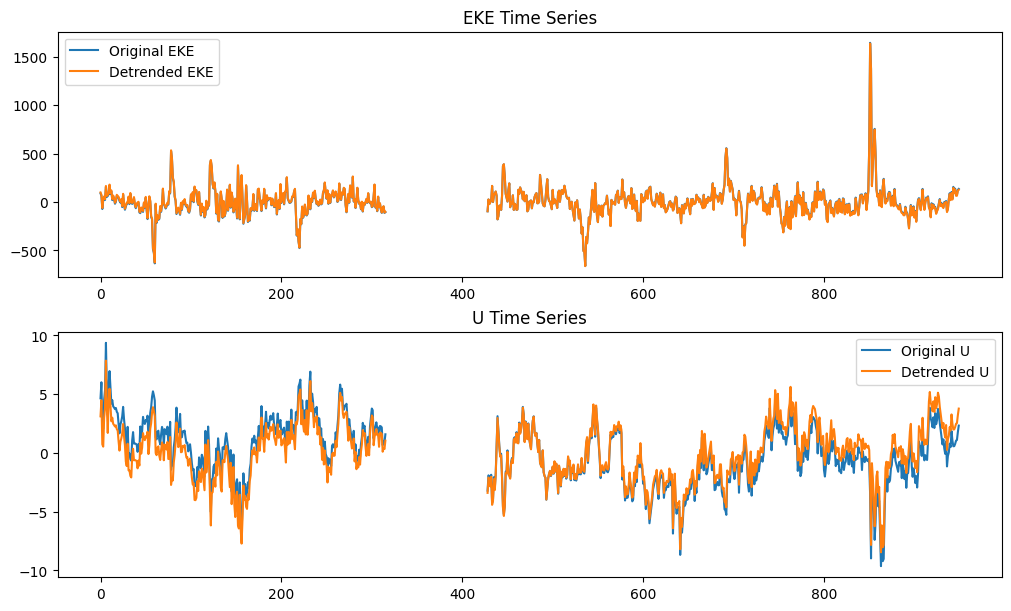

u: 47764/399000 (11.97%) NaNs
eke: 47764/399000 (11.97%) NaNs
valid time: 176 / 950


In [47]:

# Choose a specific domain:
if HEMI == "NH":
    lat_mask = (lats >= 20) & (lats <= 90) 
    eke_anom_domain = eke_anom[:, :, lat_mask]    
    u_anom_domain = u_anom[:, :, lat_mask]
    lat_hemi = lats[lat_mask]
else:
    print('change to SH target domain')
    lat_mask = (lats >= -90) & (lats <= -20) 
    eke_anom_domain = eke_anom[:, :, lat_mask]
    u_anom_domain = u_anom[:, :, lat_mask]
    lat_hemi = lats[lat_mask]

# 01 Weights (Pressure + Latitude) calculation 
sqrtLats = np.sqrt(np.abs(np.cos(np.deg2rad(lat_hemi))))
plev_bounds = np.concatenate(([plevs[0]], (plevs[:-1] + plevs[1:]) / 2, [plevs[-1]]))
dp = np.abs(np.diff(plev_bounds))
weights = np.sqrt(dp / np.max(dp))[:, None] * sqrtLats[None, :]

# 02 Detrend
eke_anom_hemi_detrend = simple_detrend_nd(eke_anom)
u_anom_hemi_detrend = simple_detrend_nd(u_anom)
# for eof:
eke_anom_detrended = simple_detrend_nd(eke_anom_domain)
u_anom_detrended   = simple_detrend_nd(u_anom_domain)

# plot to see detrend before and after time series
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
ax[0].plot(np.nanmean(eke_anom[:, :, lat_mask], axis=(1, 2)), label="Original EKE")
ax[0].plot(np.nanmean(eke_anom_detrended, axis=(1, 2)), label="Detrended EKE")
ax[0].set_title("EKE Time Series")
ax[0].legend()
ax[1].plot(np.nanmean(u_anom[:, :, lat_mask], axis=(1, 2)), label="Original U")
ax[1].plot(np.nanmean(u_anom_detrended, axis=(1, 2)), label="Detrended U")
ax[1].set_title("U Time Series")
ax[1].legend()
plt.show()

ekeZonalWeight = eke_anom_detrended * weights[None, :, :]
uZonalWeight   = u_anom_detrended   * weights[None, :, :]

# check nans:
for name, arr in [("u", uZonalWeight), ("eke", ekeZonalWeight)]:
    n_nan = np.isnan(arr).sum()
    n_total = arr.size
    print(f"{name}: {n_nan}/{n_total} ({100*n_nan/n_total:.2f}%) NaNs")
# keep only the time steps where both u and eke are finite across all levels and latitudes
valid_time = (
    np.all(np.isfinite(uZonalWeight), axis=(1, 2)) &
    np.all(np.isfinite(ekeZonalWeight), axis=(1, 2))
)
print("valid time:", valid_time.sum(), "/", len(valid_time))
u_eof_input   = uZonalWeight[valid_time]
eke_eof_input = ekeZonalWeight[valid_time]

# 03 EOF Calculation (run time estimate: 1 min)
sol_sam = Eof(u_eof_input) # SAM (for SH) or NAM (for NH).
sol_bam = Eof(eke_eof_input)

# 04 Make PC time series consistent with original time series length,
# GDS days = NaN
# valid days = PC values
pc_sam_valid = sol_sam.pcs(npcs=1)[:, 0]
pc_bam_valid = sol_bam.pcs(npcs=1)[:, 0]

pc_sam_valid = (pc_sam_valid - np.nanmean(pc_sam_valid)) / np.nanstd(pc_sam_valid)
pc_bam_valid = (pc_bam_valid - np.nanmean(pc_bam_valid)) / np.nanstd(pc_bam_valid)

pc_sam = np.full(len(valid_time), np.nan)
pc_bam = np.full(len(valid_time), np.nan)

pc_sam[valid_time] = pc_sam_valid
pc_bam[valid_time] = pc_bam_valid

(30, 14)
(950, 30, 14)


/tmp/ipykernel_2223485/417198073.py:5: RuntimeWarning: Mean of empty slice
  u_domain_mean_ts = np.nanmean(u_anom_domain, axis=(1, 2))


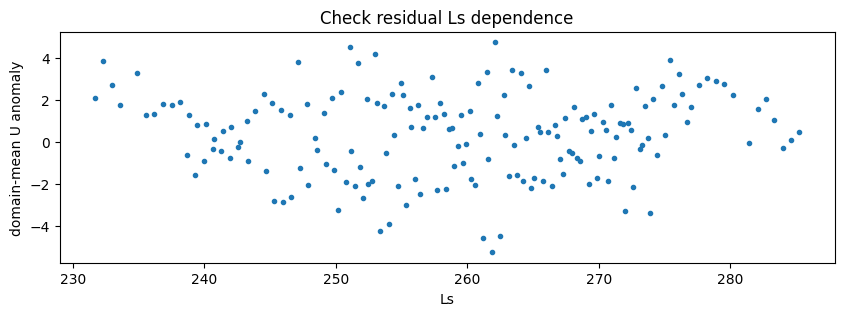

0.5083938711572564


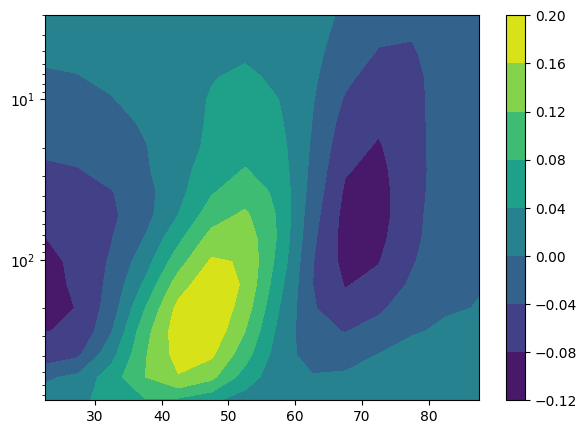

0.5018319071733729


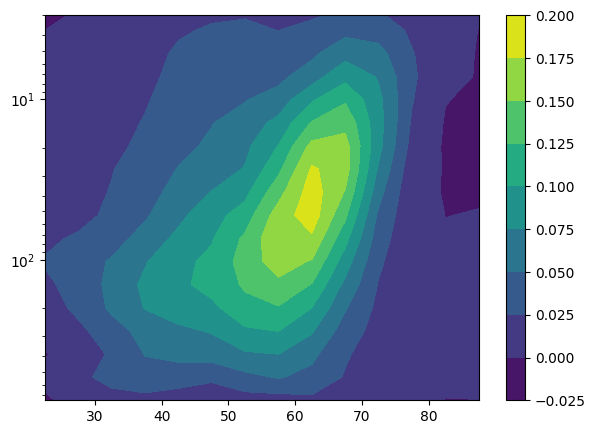

In [62]:
print(weights.shape)

print(u_anom_detrended.shape)

u_domain_mean_ts = np.nanmean(u_anom_domain, axis=(1, 2))

plt.figure(figsize=(10, 3))
plt.plot(Ls[valid_time], u_domain_mean_ts[valid_time], ".")
plt.xlabel("Ls")
plt.ylabel("domain-mean U anomaly")
plt.title("Check residual Ls dependence")
plt.show()

print(sol_sam.varianceFraction(neigs=10)[0])

# nam
plt.figure(figsize=(7, 5))
eof1 = sol_sam.eofs(neofs=1)[0]
plt.contourf(lat_hemi, plevs, eof1)
plt.yscale('log')
plt.ylim(750, 3)
# add colorbar
plt.colorbar()
# plt.gca().invert_yaxis()
plt.show()

print(sol_bam.varianceFraction(neigs=10)[0])
# bam
plt.figure(figsize=(7, 5))
eof1 = sol_bam.eofs(neofs=1)[0]
plt.contourf(lat_hemi, plevs, eof1)
plt.yscale('log')
plt.ylim(750, 3)
plt.colorbar()
# plt.gca().invert_yaxis()
plt.show()

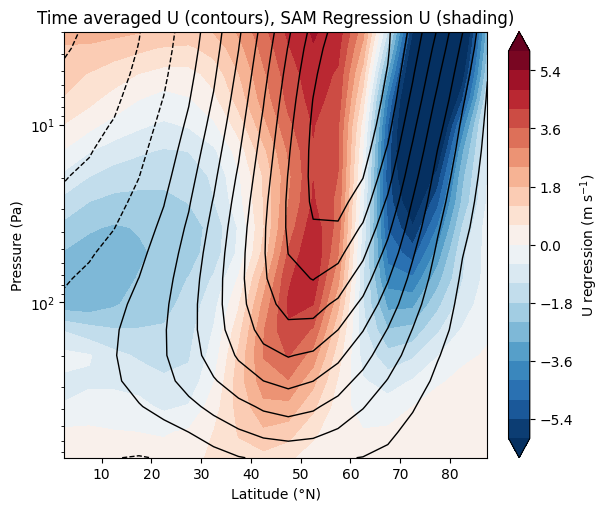

In [67]:

MYmin = np.nanmin(my)
MYmax = np.nanmax(my)

# REGRESSIONS & PLOTTING
# ------------------------------------------------------------
regr_sam_eke = lagged_regression(pc_sam, eke_anom_hemi_detrend, lag=0)
regr_sam_u = lagged_regression(pc_sam, u_anom_hemi_detrend, lag=0)
regr_bam_eke = lagged_regression(pc_bam, eke_anom_hemi_detrend, lag=0)
regr_bam_u = lagged_regression(pc_bam, u_anom_hemi_detrend, lag=0)

# Plotting
import numpy as np
import matplotlib.pyplot as plt

# shading: u regression
# contours: EKE regression
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# color levels
m = np.nanmax(np.abs(regr_sam_u))
regu_levels = np.linspace(-6, 6, 21)

# contour levels
m = np.nanmax(np.abs(uZonal_mean))
u_levels = np.linspace(-40, 120, 11)

# shading (regression U)
cf = ax.contourf(
    lats, plevs, regr_sam_u,
    levels=regu_levels,
    cmap="RdBu_r",
    extend="both"
)
plt.colorbar(cf, ax=ax, label="U regression (m s$^{-1}$)")

# zonal u mean
ax.contour(
    lats, plevs, uZonal_mean,
    levels=[l for l in u_levels if l < 0],
    colors="k",
    linestyles="dashed",
    linewidths=1,
)

ax.contour(
    lats, plevs, uZonal_mean,
    levels=[l for l in u_levels if l > 0],
    colors="k",
    linestyles="solid",
    linewidths=1,
)

ax.set_yscale("log")
ax.set_ylim(750, 3)
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Pressure (Pa)")
ax.set_title("Time averaged U (contours), SAM Regression U (shading)")

plt.show()

